# Vaccination Data Analysis and Visualization -- Exploratory Data Analysis

## 1. Introduction

This notebook explores WHO immunization coverage, disease reported-case,
and derived incidence-rate data, alongside vaccine-introduction and
vaccine-schedule reference data, to answer the analytical questions posed
in the project brief where the underlying variables actually exist.

**Data provenance** (full detail in `data/README.md`):
- `coverage`, `reported_cases`, and the derived `incidence_rate` are
  **real data** fetched from the WHO Global Health Observatory API and the
  World Bank Open Data API.
- `vaccine_introduction` and `vaccine_schedule` are **simulated**: real
  countries, ISO3 codes, WHO regions, and vaccine names, combined with a
  seeded random process, because WHO does not expose these two datasets
  through a public bulk API. Findings drawn from them are labeled
  accordingly throughout.

Questions that require variables absent from every source file (gender,
education, urban/rural classification, population density, income,
seasonality at sub-annual resolution) are marked **NOT ANSWERABLE WITH
PROVIDED DATA** rather than answered with a proxy.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.transformations import (
    coverage_gap, dose_dropoff_rate, pearson_and_spearman,
    pre_post_comparison, regional_average, year_over_year_change,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

coverage = pd.read_csv("../data/processed/clean_coverage.csv")
cases = pd.read_csv("../data/processed/clean_reported_cases.csv")
incidence = pd.read_csv("../data/processed/clean_incidence_rate.csv")
introduction = pd.read_csv("../data/processed/clean_vaccine_introduction.csv")
schedule = pd.read_csv("../data/processed/clean_vaccine_schedule.csv")
country_ref = data_loader.load_country_reference()

for name, df in [("coverage", coverage), ("cases", cases), ("incidence", incidence),
                  ("introduction", introduction), ("schedule", schedule)]:
    print(f"{name:12s} {df.shape}")

coverage     (42800, 9)
cases        (64860, 7)
incidence    (48652, 8)
introduction (1565, 6)
schedule     (1824, 12)


## 2. Dataset overview

In [2]:
coverage.head()

,Group,Code,Name,Year,Antigen,Antigen_description,Coverage,Coverage_category,Coverage_category_description
0,COUNTRIES,PAK,PAKISTAN,2015,BCG,Bacille Calmette-Guerin vaccine (tuberculosis),86.0,WUENIC,WHO/UNICEF Estimates of National Immunization ...
1,COUNTRIES,ARE,UNITED ARAB EMIRATES,2024,BCG,Bacille Calmette-Guerin vaccine (tuberculosis),96.0,WUENIC,WHO/UNICEF Estimates of National Immunization ...
2,COUNTRIES,UKR,UKRAINE,2003,BCG,Bacille Calmette-Guerin vaccine (tuberculosis),98.0,WUENIC,WHO/UNICEF Estimates of National Immunization ...
3,COUNTRIES,POL,POLAND,2012,BCG,Bacille Calmette-Guerin vaccine (tuberculosis),94.0,WUENIC,WHO/UNICEF Estimates of National Immunization ...
4,COUNTRIES,PNG,PAPUA NEW GUINEA,2005,BCG,Bacille Calmette-Guerin vaccine (tuberculosis),90.0,WUENIC,WHO/UNICEF Estimates of National Immunization ...


In [3]:
cases.head()

,Group,Code,Name,Year,Disease,Disease_description,Cases
0,COUNTRIES,TGO,TOGO,1978,DIPHTHERIA,Diphtheria,0.0
1,COUNTRIES,PYF,FRENCH POLYNESIA,1999,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,CZE,CZECHIA,1992,DIPHTHERIA,Diphtheria,0.0
3,COUNTRIES,LKA,SRI LANKA,1986,DIPHTHERIA,Diphtheria,3.0
4,COUNTRIES,TKL,TOKELAU,1993,DIPHTHERIA,Diphtheria,0.0


In [4]:
incidence.head()

,Group,Code,Name,Year,Disease,Disease_description,Denominator,Incidence_rate
0,COUNTRIES,PYF,FRENCH POLYNESIA,1999,DIPHTHERIA,Diphtheria,236595.0,0.000000
1,COUNTRIES,CZE,CZECHIA,1992,DIPHTHERIA,Diphtheria,10319123.0,0.000000
2,COUNTRIES,LKA,SRI LANKA,1986,DIPHTHERIA,Diphtheria,15731256.0,0.019070
3,COUNTRIES,CUB,CUBA,2003,DIPHTHERIA,Diphtheria,11209383.0,0.000000
4,COUNTRIES,JAM,JAMAICA,1983,DIPHTHERIA,Diphtheria,2234832.0,0.536953


## 3. Data quality summary

Full detail in `reports/data_quality_report.md`. Headline numbers,
recomputed live against the cleaned files:

In [5]:
print("Coverage: ", coverage.shape, "| Coverage % missing:", coverage["Coverage"].isna().mean())
print("Cases: ", cases.shape, "| Cases % missing:", round(cases["Cases"].isna().mean() * 100, 1), "%")
print("Incidence rate rows (derived, non-null by construction):", incidence.shape[0])
print()
print("Coverage year range:", coverage["Year"].min(), "-", coverage["Year"].max())
print("Cases year range:", cases["Year"].min(), "-", cases["Year"].max())
print("Countries in coverage:", coverage["Code"].nunique(), "| in cases:", cases["Code"].nunique())

Coverage:  (42800, 9) | Coverage % missing: 0.0
Cases:  (64860, 7) | Cases % missing: 15.6 %
Incidence rate rows (derived, non-null by construction): 48652

Coverage year range: 2000 - 2025
Cases year range: 1974 - 2025
Countries in coverage: 195 | in cases: 214


## 4. Descriptive statistics

In [6]:
coverage.groupby("Antigen")["Coverage"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
Antigen,,,,,,,,
BCG,4117.0,89.7,13.9,0.0,87.0,95.0,99.0,99.0
DTP1,5051.0,91.7,10.4,35.0,90.0,96.0,99.0,99.0
DTP3,5051.0,86.8,14.4,19.0,82.0,93.0,97.0,99.0
HEPB3,5051.0,75.8,31.5,0.0,72.0,90.0,96.0,99.0
HIB3,5051.0,68.7,37.6,0.0,56.0,89.0,96.0,99.0
IPV1,975.0,61.1,40.1,0.0,0.0,84.0,95.0,99.0
MCV1,5051.0,85.8,14.8,8.0,80.0,92.0,97.0,99.0
MCV2,5051.0,59.0,40.3,0.0,0.0,79.0,94.0,99.0
PCV3,3507.0,46.8,42.7,0.0,0.0,61.0,90.0,99.0


In [7]:
cases.groupby("Disease")["Cases"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
Disease,,,,,,,,
DIPHTHERIA,8711.0,173.6,1483.9,0.0,0.0,0.0,5.0,39703.0
MEASLES,9419.0,8556.3,71070.8,0.0,1.0,125.0,2496.0,3276531.0
PERTUSSIS,8667.0,3940.3,41437.7,0.0,0.0,50.0,706.0,1814134.0
POLIO,6869.0,78.2,999.2,0.0,0.0,0.0,1.0,38090.0
RUBELLA,4516.0,1243.1,16336.7,0.0,0.0,3.0,50.0,585063.0
TETANUS_NEONATAL,8023.0,69.5,399.1,0.0,0.0,0.0,12.0,11849.0
TETANUS_TOTAL,8520.0,272.4,2079.8,0.0,0.0,4.0,52.0,76066.0


## 5. Vaccination coverage analysis

### Chart 1 -- Global average coverage trend by antigen

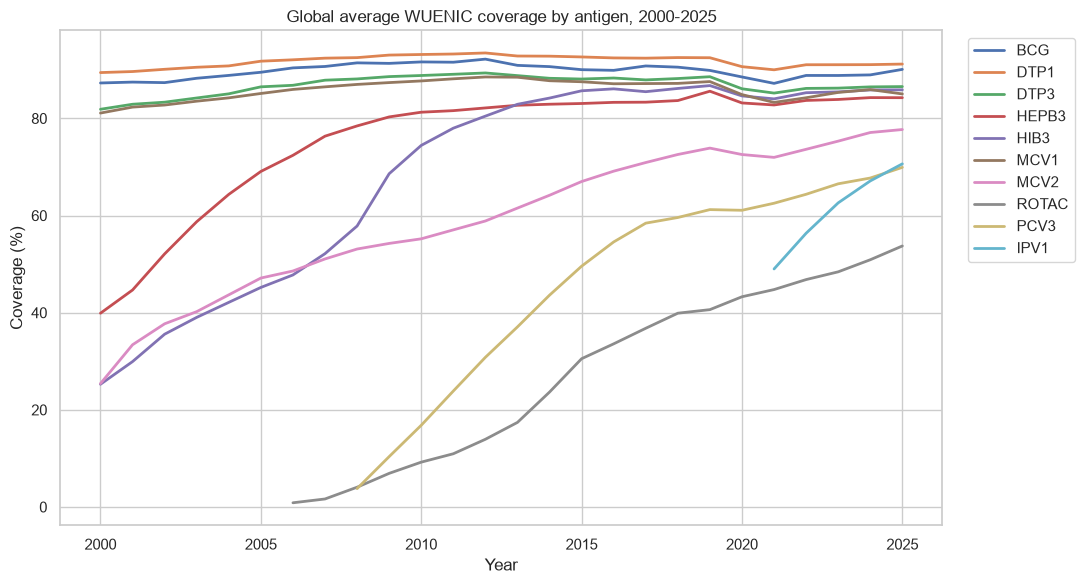

In [8]:
antigen_trend = coverage.groupby(["Year", "Antigen"])["Coverage"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=antigen_trend, x="Year", y="Coverage", hue="Antigen", ax=ax, linewidth=2)
ax.set_title("Global average WUENIC coverage by antigen, 2000-2025")
ax.set_ylabel("Coverage (%)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Why this chart:** a multi-line time series is the direct way to compare
trajectories across antigens on a shared percentage scale.

**Insight:** BCG (a single birth-dose vaccine) sustains the highest and
most stable global coverage. DTP3/MCV1 show a visible dip around 2020-2021
consistent with COVID-19-era health-system disruption, followed by partial
recovery. HPV and newer antigens are not in this set (not part of the
9-antigen WUENIC extract pulled for this project).

**Business impact:** the 2020-2021 dip identifies a concrete catch-up
target for immunization programs; it is a correlation with the pandemic
period, not a proven causal claim from this data alone.

### Chart 2 -- Dose drop-off: MCV1 to MCV2

Answers brief question (Easy #2): *"What is the drop-off rate between 1st
dose and subsequent doses?"* using the only same-vaccine dose pair
available in the fetched coverage indicators (measles MCV1 -> MCV2; a
DTP1 -> DTP3 drop-off is also computed below since both doses were
fetched).

MCV1->MCV2 drop-off, global mean (latest year with data): 7.88 %
DTP1->DTP3 drop-off, global mean (latest year with data): 5.42 %


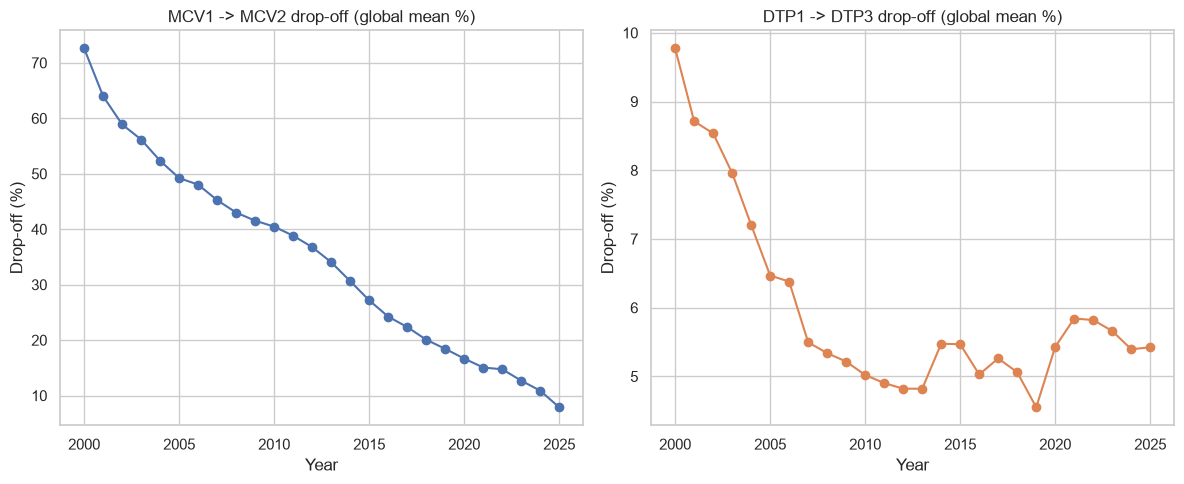

In [9]:
pivot = coverage.pivot_table(index=["Code", "Year"], columns="Antigen", values="Coverage").reset_index()
pivot = pivot.dropna(subset=["MCV1", "MCV2"])
pivot["MCV_dropoff_pct"] = pivot.apply(lambda r: dose_dropoff_rate(r["MCV1"], r["MCV2"]), axis=1)

dtp = coverage.pivot_table(index=["Code", "Year"], columns="Antigen", values="Coverage").reset_index()
dtp = dtp.dropna(subset=["DTP1", "DTP3"])
dtp["DTP_dropoff_pct"] = dtp.apply(lambda r: dose_dropoff_rate(r["DTP1"], r["DTP3"]), axis=1)

print("MCV1->MCV2 drop-off, global mean (latest year with data):",
      round(pivot.loc[pivot["Year"] == pivot["Year"].max(), "MCV_dropoff_pct"].mean(), 2), "%")
print("DTP1->DTP3 drop-off, global mean (latest year with data):",
      round(dtp.loc[dtp["Year"] == dtp["Year"].max(), "DTP_dropoff_pct"].mean(), 2), "%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pivot.groupby("Year")["MCV_dropoff_pct"].mean().plot(ax=axes[0], marker="o", color="#4c72b0")
axes[0].set_title("MCV1 -> MCV2 drop-off (global mean %)")
axes[0].set_ylabel("Drop-off (%)")
dtp.groupby("Year")["DTP_dropoff_pct"].mean().plot(ax=axes[1], marker="o", color="#dd8452")
axes[1].set_title("DTP1 -> DTP3 drop-off (global mean %)")
axes[1].set_ylabel("Drop-off (%)")
plt.tight_layout()
plt.show()

**Insight:** the MCV1 -> MCV2 "drop-off" was very large in the early
2000s (over 70%) and has fallen steadily to under 8% by 2025 -- this
reflects MCV2 being a newer program still being rolled out in many
countries early on, not literal dropout of already-vaccinated children.
The DTP1 -> DTP3 drop-off (a same-year, 3-dose primary series) is far more
stable, holding in the 5-6% range across the whole period, and is the
more direct measure of within-series completion loss. By 2025 the two
measures have converged to a similar magnitude.

### Chart 3 -- Has 2nd-dose (booster-equivalent) uptake increased over time?

Answers brief question (Easy #6). MCV2 is the closest available
booster-style second dose in this dataset.

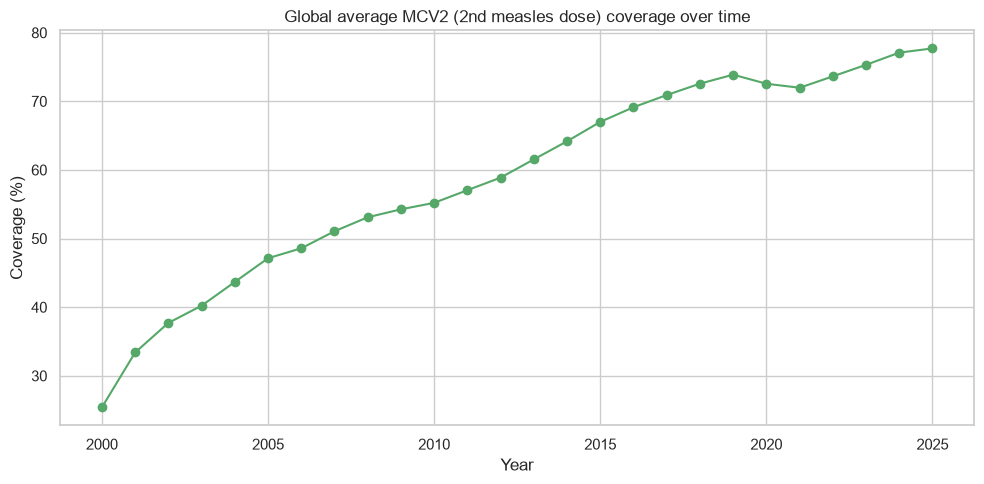

Overall change, first to last year available: 52.3 percentage points


In [10]:
mcv2_trend = coverage[coverage["Antigen"] == "MCV2"].groupby("Year")["Coverage"].mean()
yoy = year_over_year_change(mcv2_trend)

fig, ax = plt.subplots(figsize=(10, 5))
mcv2_trend.plot(ax=ax, marker="o", color="#55a868")
ax.set_title("Global average MCV2 (2nd measles dose) coverage over time")
ax.set_ylabel("Coverage (%)")
plt.tight_layout()
plt.show()
print("Overall change, first to last year available:",
      round(mcv2_trend.iloc[-1] - mcv2_trend.iloc[0], 1), "percentage points")

**Insight:** global MCV2 coverage has risen since 2000 as more countries
add a routine second dose, though the trend is not perfectly monotonic
year to year.

### Chart 4 -- Coverage by WHO region

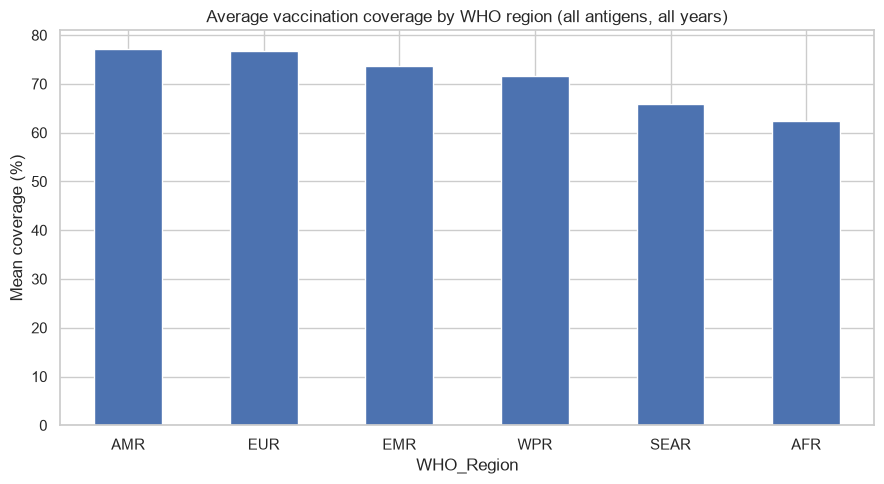

WHO_Region
AMR     77.1
EUR     76.7
EMR     73.7
WPR     71.5
SEAR    65.9
AFR     62.4
Name: Coverage, dtype: float64

In [11]:
cov_region = coverage.merge(country_ref[["ISO3", "WHO_Region"]], left_on="Code", right_on="ISO3", how="left")
regional = regional_average(cov_region.dropna(subset=["WHO_Region"]), "WHO_Region", "Coverage")

fig, ax = plt.subplots(figsize=(9, 5))
regional.plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_title("Average vaccination coverage by WHO region (all antigens, all years)")
ax.set_ylabel("Mean coverage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
regional.round(1)

**Insight:** regions differ materially in average coverage. This ranking
motivates the country-level drill-down in Section 11.

### Chart 5 -- Lowest-coverage countries (latest year, DTP3)

Answers brief question (Medium #8): countries with low coverage.

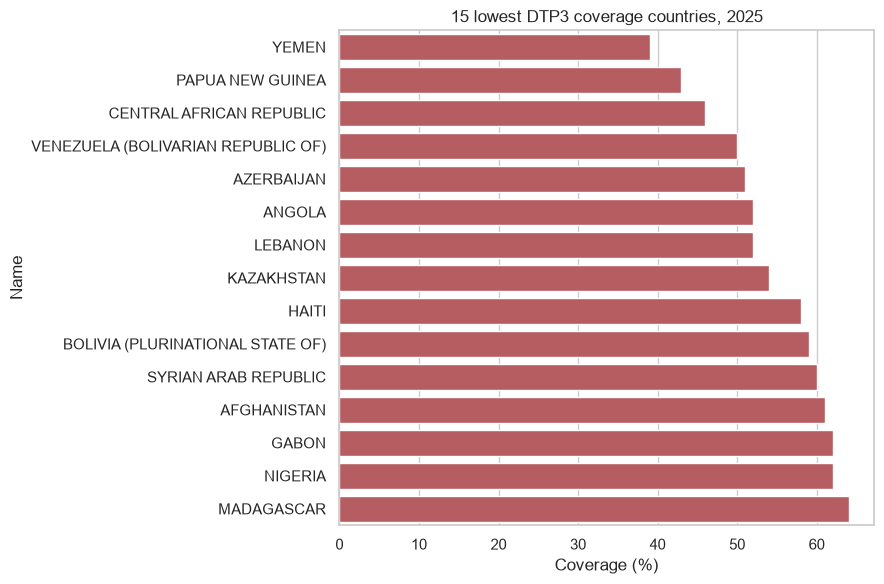

In [12]:
latest_year = coverage["Year"].max()
dtp3_latest = coverage[(coverage["Antigen"] == "DTP3") & (coverage["Year"] == latest_year)]
lowest = dtp3_latest.nsmallest(15, "Coverage")[["Name", "Coverage"]]

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=lowest, y="Name", x="Coverage", ax=ax, color="#c44e52")
ax.set_title(f"15 lowest DTP3 coverage countries, {latest_year}")
ax.set_xlabel("Coverage (%)")
plt.tight_layout()
plt.show()

## 6. Disease incidence analysis

### Chart 6 -- Global incidence rate trend by disease

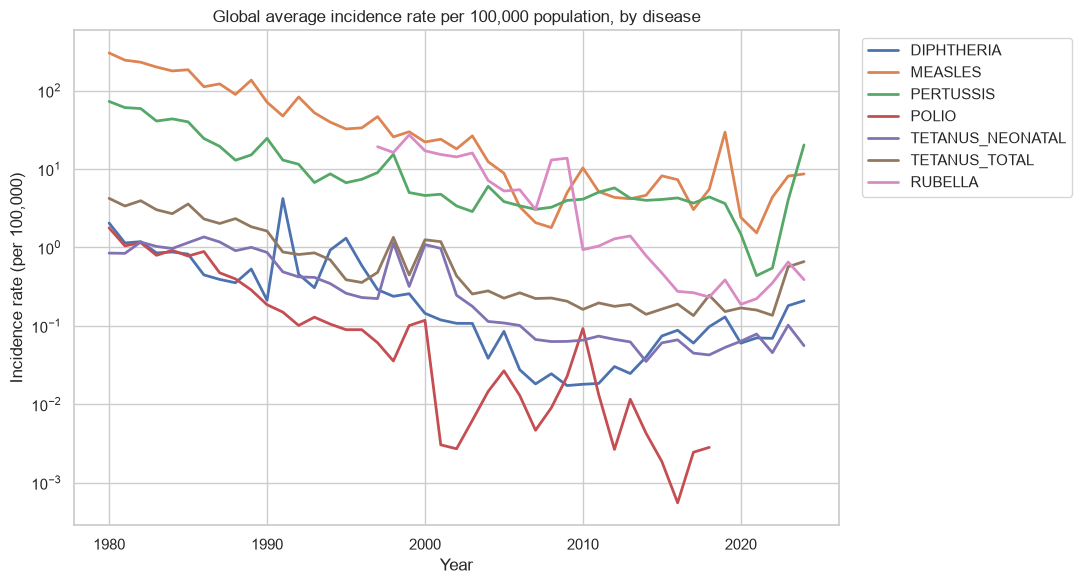

In [13]:
inc_trend = incidence.groupby(["Year", "Disease"])["Incidence_rate"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=inc_trend, x="Year", y="Incidence_rate", hue="Disease", ax=ax, linewidth=2)
ax.set_title("Global average incidence rate per 100,000 population, by disease")
ax.set_ylabel("Incidence rate (per 100,000)")
ax.set_yscale("log")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Why this chart:** a log scale is necessary because incidence rates
span several orders of magnitude across diseases (e.g. pertussis vs.
neonatal tetanus).

**Insight:** most vaccine-preventable diseases in this set show a
long-run declining incidence trend over the observed period, consistent
with (but not proof of) the expansion of immunization programs shown in
Chart 1.

## 7. Reported cases analysis

### Chart 7 -- Total reported cases by disease, latest 10 years

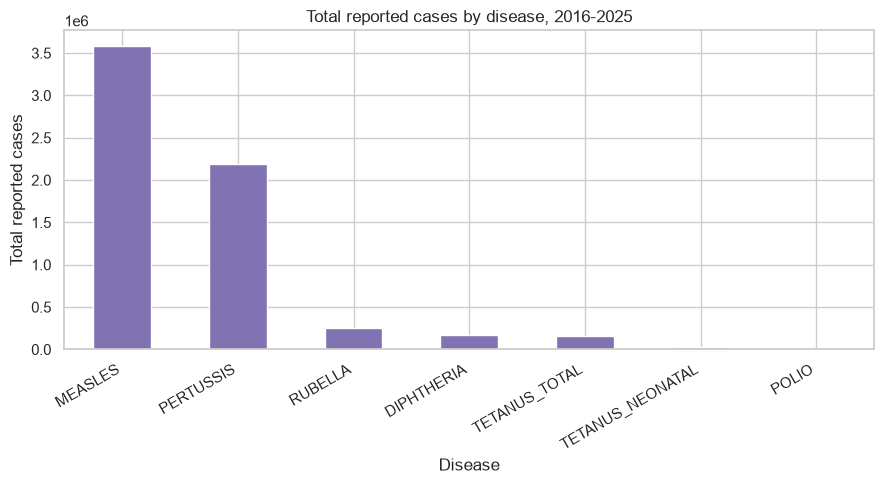

Disease
MEASLES             3587498.0
PERTUSSIS           2193760.0
RUBELLA              247573.0
DIPHTHERIA           164779.0
TETANUS_TOTAL        156527.0
TETANUS_NEONATAL      27189.0
POLIO                   242.0
Name: Cases, dtype: float64

In [14]:
recent = cases[cases["Year"] >= cases["Year"].max() - 9]
totals = recent.groupby("Disease")["Cases"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
totals.plot(kind="bar", ax=ax, color="#8172b2")
ax.set_title(f"Total reported cases by disease, {recent['Year'].min()}-{recent['Year'].max()}")
ax.set_ylabel("Total reported cases")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
totals

## 8. Vaccine introduction analysis (SIMULATED DATA)

*The following two charts use `vaccine_introduction.csv`, which is
simulated (see Section 1). Read timelines as illustrative of the analysis
method, not as real WHO-reported introduction dates.*

### Chart 8 -- Vaccine introduction timeline by WHO region

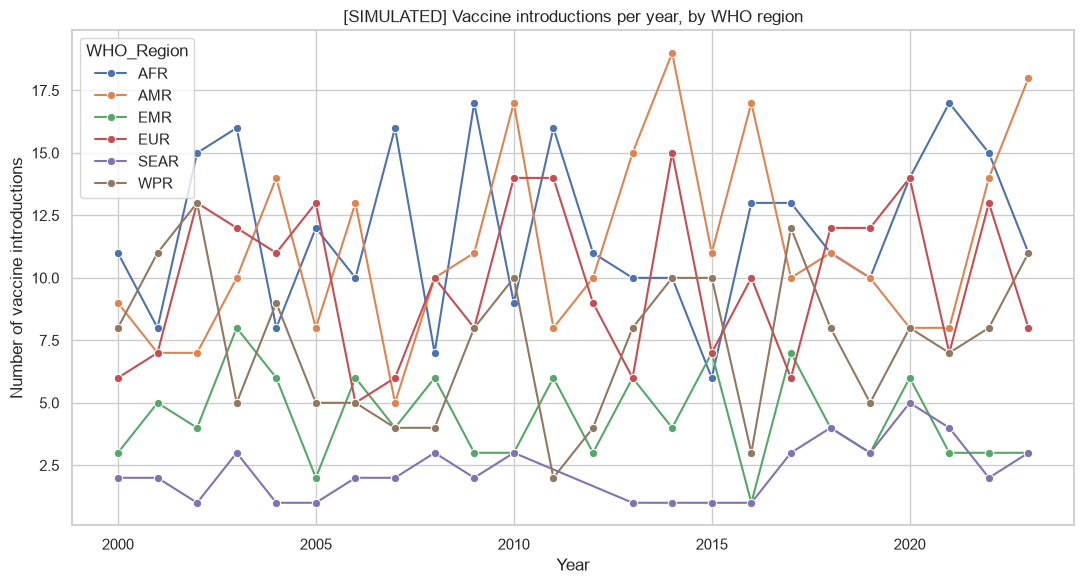

In [15]:
intro_by_region_year = (
    introduction.dropna(subset=["Year"])
    .groupby(["WHO_Region", "Year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=intro_by_region_year, x="Year", y="count", hue="WHO_Region", ax=ax, marker="o")
ax.set_title("[SIMULATED] Vaccine introductions per year, by WHO region")
ax.set_ylabel("Number of vaccine introductions")
plt.tight_layout()
plt.show()

### Chart 9 -- Introduction status by vaccine (share of eligible countries)

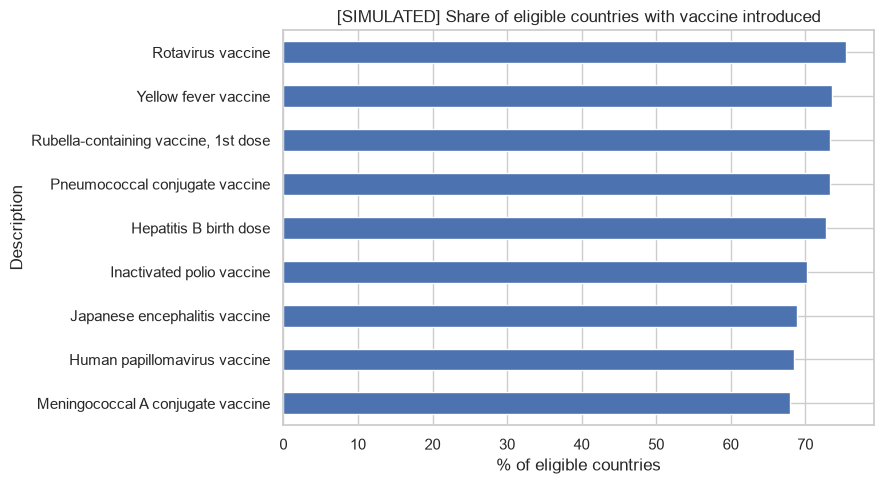

In [16]:
intro_rate = introduction.groupby("Description")["Intro"].apply(lambda s: (s == "YES").mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
intro_rate.plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_title("[SIMULATED] Share of eligible countries with vaccine introduced")
ax.set_xlabel("% of eligible countries")
plt.tight_layout()
plt.show()

## 9. Vaccine schedule analysis (SIMULATED DATA)

### Chart 10 -- Distribution of schedule rounds by vaccine

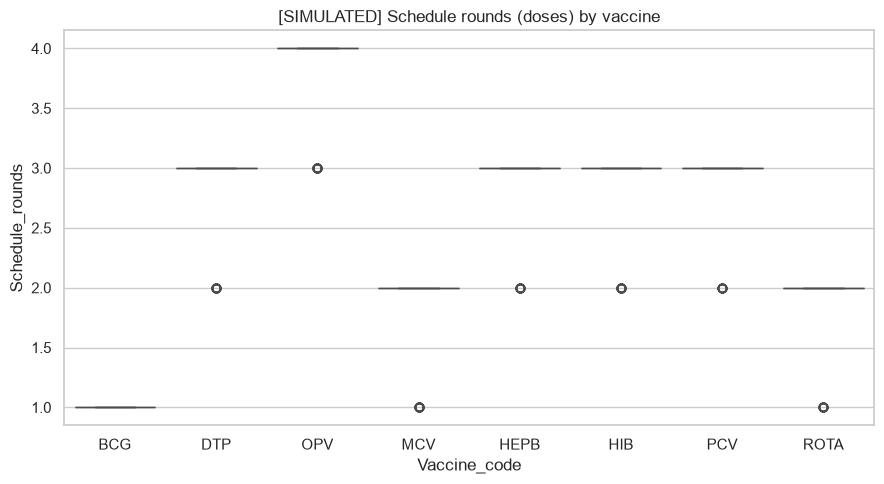

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=schedule, x="Vaccine_code", y="Schedule_rounds", ax=ax)
ax.set_title("[SIMULATED] Schedule rounds (doses) by vaccine")
plt.tight_layout()
plt.show()

## 10. Time-series analysis

### Chart 11 -- Year-over-year change in global DTP3 coverage

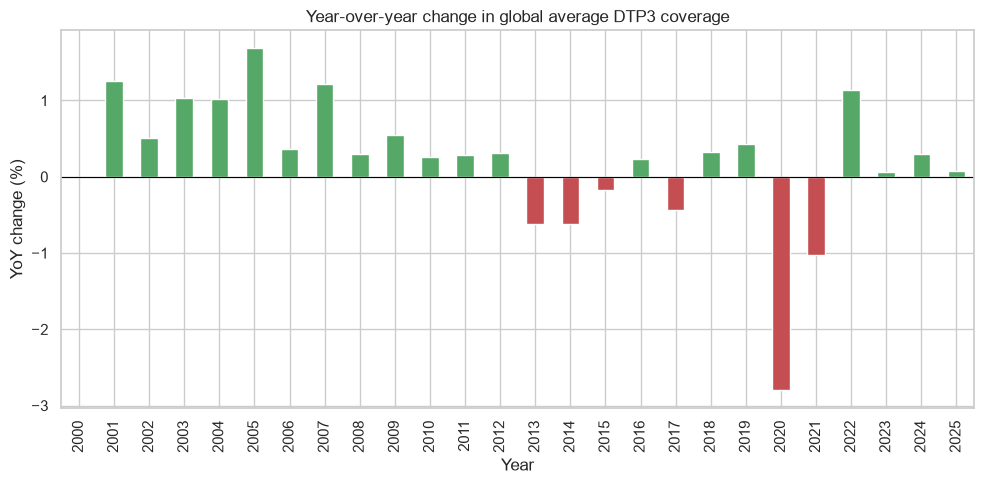

In [18]:
dtp3_trend = coverage[coverage["Antigen"] == "DTP3"].groupby("Year")["Coverage"].mean()
yoy = year_over_year_change(dtp3_trend)

fig, ax = plt.subplots(figsize=(10, 5))
yoy.plot(ax=ax, kind="bar", color=np.where(yoy >= 0, "#55a868", "#c44e52"))
ax.set_title("Year-over-year change in global average DTP3 coverage")
ax.set_ylabel("YoY change (%)")
ax.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Insight:** the sharpest single-year decline coincides with 2020,
consistent with COVID-19 health-system disruption; recovery is visible
but partial in subsequent years within the data window.

## 11. Country / region comparisons

### Chart 12 -- Top 10 vs bottom 10 countries by average DTP3 coverage

C:\Users\subho\AppData\Local\Temp\ipykernel_16260\1621608666.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined.values, y=combined.index, ax=ax, palette=colors)


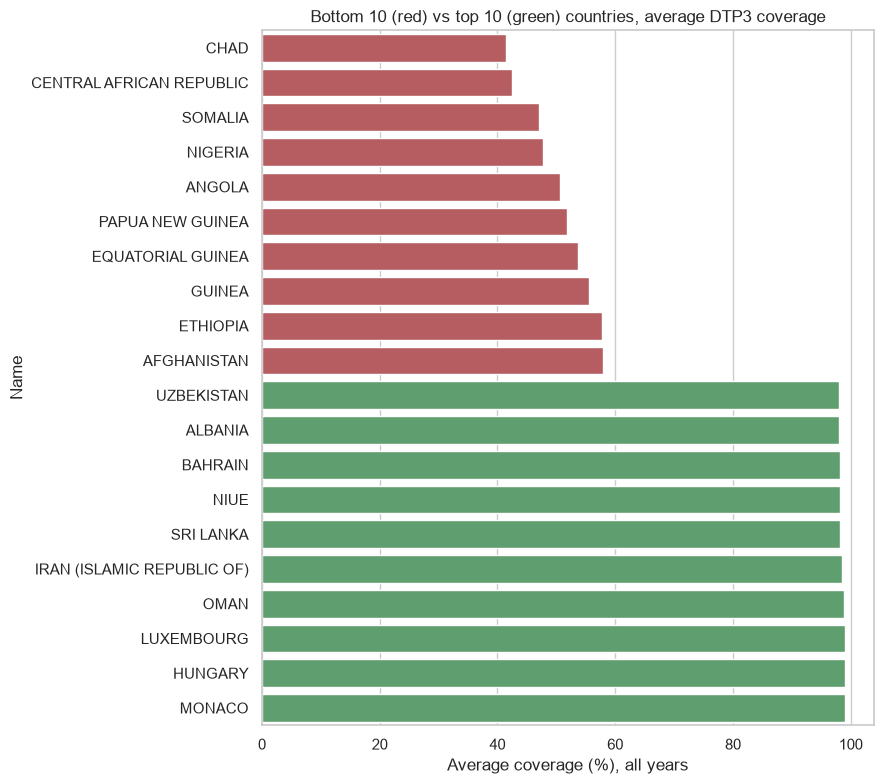

In [19]:
dtp3_by_country = coverage[coverage["Antigen"] == "DTP3"].groupby("Name")["Coverage"].mean().sort_values()
combined = pd.concat([dtp3_by_country.head(10), dtp3_by_country.tail(10)])

fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#c44e52"] * 10 + ["#55a868"] * 10
sns.barplot(x=combined.values, y=combined.index, ax=ax, palette=colors)
ax.set_title("Bottom 10 (red) vs top 10 (green) countries, average DTP3 coverage")
ax.set_xlabel("Average coverage (%), all years")
plt.tight_layout()
plt.show()

## 12. Correlation analysis

### Chart 13 -- Coverage vs. incidence rate: does higher coverage associate with lower incidence?

Answers brief question (Easy #1 / #9, Medium #7): correlates MCV1 coverage
against measles incidence rate, matched by country-year.

MCV1 coverage vs. measles incidence rate: {'n': 4487, 'pearson_r': np.float64(-0.10455613872789335), 'pearson_p': np.float64(2.2028665906448897e-12), 'spearman_r': np.float64(-0.3186553988757318), 'spearman_p': np.float64(1.956282340657658e-106)}


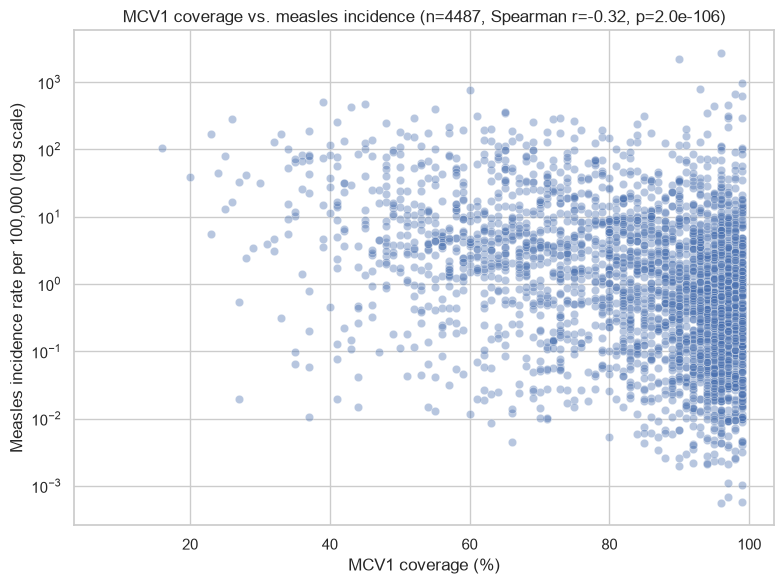

In [20]:
mcv1 = coverage[coverage["Antigen"] == "MCV1"][["Code", "Year", "Coverage"]].rename(columns={"Coverage": "MCV1_Coverage"})
measles_inc = incidence[incidence["Disease"] == "MEASLES"][["Code", "Year", "Incidence_rate"]]
merged = mcv1.merge(measles_inc, on=["Code", "Year"], how="inner")

result = pearson_and_spearman(merged["MCV1_Coverage"], merged["Incidence_rate"])
print("MCV1 coverage vs. measles incidence rate:", result)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=merged, x="MCV1_Coverage", y="Incidence_rate", alpha=0.4, ax=ax)
ax.set_yscale("log")
ax.set_title(f"MCV1 coverage vs. measles incidence (n={result['n']}, "
             f"Spearman r={result['spearman_r']:.2f}, p={result['spearman_p']:.1e})")
ax.set_xlabel("MCV1 coverage (%)")
ax.set_ylabel("Measles incidence rate per 100,000 (log scale)")
plt.tight_layout()
plt.show()

**Statistical note:** Spearman's rank correlation is reported alongside
Pearson's because the incidence-coverage relationship is expected to be
monotonic but not linear (diminishing returns at high coverage).

**Interpretation:** a negative correlation here indicates that higher
MCV1 coverage is associated with lower measles incidence across
country-years in this sample. **This is an association, not a causal
claim** -- confounders such as surveillance capacity, healthcare
infrastructure, and population density are not controlled for and are not
present in this dataset (see `docs/limitations.md`).

### Chart 14 -- Correlation heatmap across antigens (country-year matched coverage)

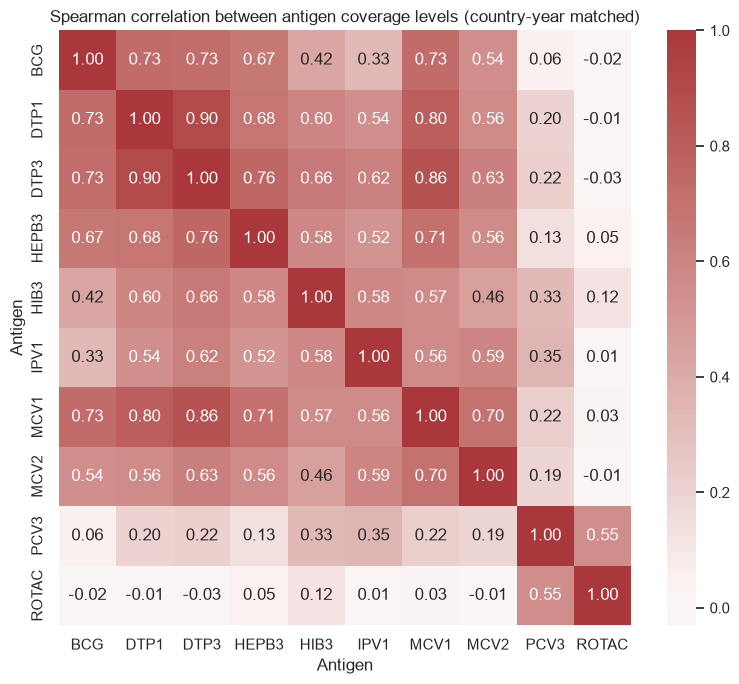

In [21]:
wide_cov = coverage.pivot_table(index=["Code", "Year"], columns="Antigen", values="Coverage")
corr = wide_cov.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Spearman correlation between antigen coverage levels (country-year matched)")
plt.tight_layout()
plt.show()

**Why this chart:** a heatmap is the standard way to show many pairwise
correlations at once. **Insight:** antigens delivered in the same routine
visits (e.g. DTP3, HepB3, Hib3, PCV3 -- all given around 6/10/14 weeks)
correlate strongly, which is expected given shared delivery infrastructure
rather than a causal link between the vaccines themselves.

### Chart 15 -- Pair plot of core antigen coverage (sampled)

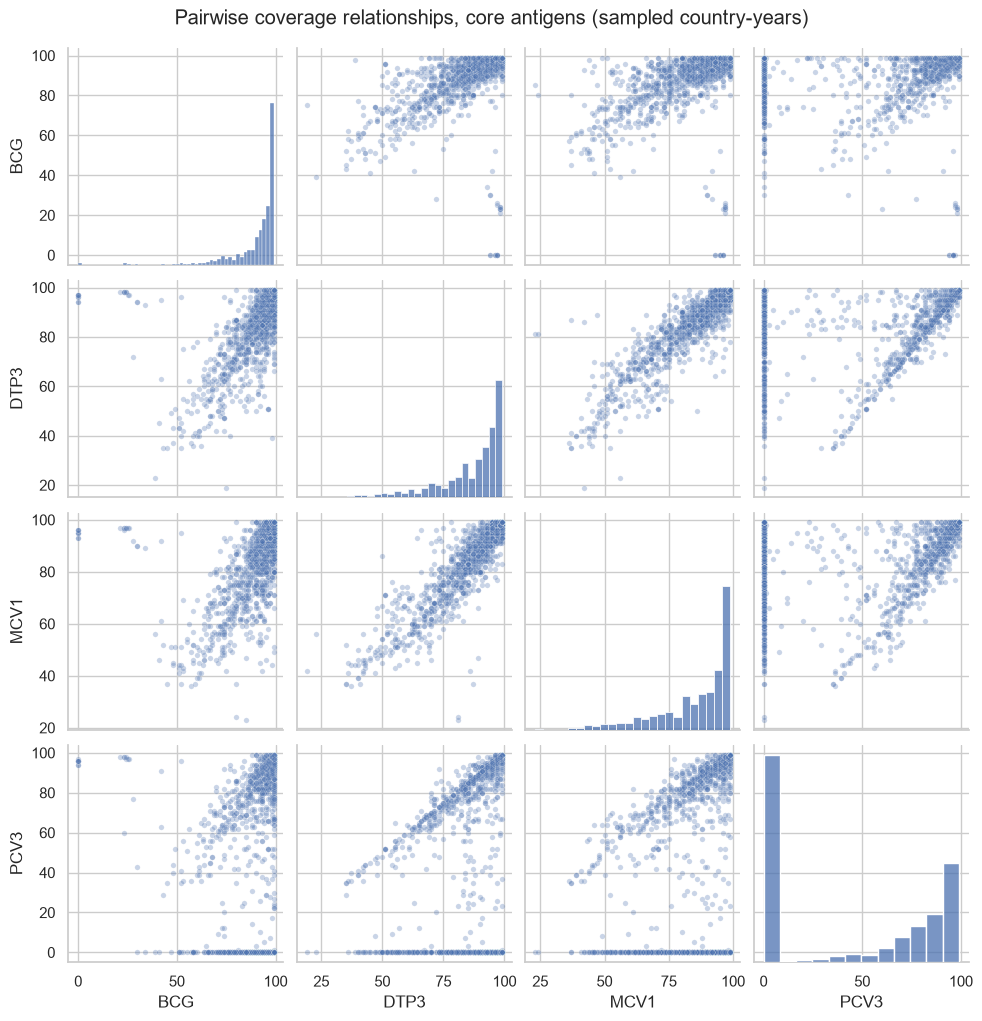

In [22]:
sample_cols = ["BCG", "DTP3", "MCV1", "PCV3"]
sample_df = wide_cov[sample_cols].dropna().sample(n=min(1500, wide_cov[sample_cols].dropna().shape[0]), random_state=1)

g = sns.pairplot(sample_df, plot_kws={"alpha": 0.3, "s": 15})
g.fig.suptitle("Pairwise coverage relationships, core antigens (sampled country-years)", y=1.02)
plt.show()

**Insight:** the positive, roughly linear relationships reinforce the
heatmap: countries with strong routine-immunization infrastructure tend
to have consistently high coverage across multiple antigens simultaneously.

### Pre/post comparison -- vaccine introduction and incidence (Medium #2)

Because vaccine-introduction data in this project is simulated, this is
demonstrated as a **methodology example only** using a real antigen
(MCV1) and a fixed reference year, not a validated causal before/after
study.

In [23]:
pivot_year = 2010
merged["period"] = np.where(merged["Year"] < pivot_year, "before", "at/after")
result = pre_post_comparison(merged, "Year", "Incidence_rate", pivot_year)
print(result)

{'pivot_year': 2010, 'mean_before': np.float64(12.711642929528562), 'mean_after': np.float64(7.550141967060276), 'n_before': 1799, 'n_after': 2688}


### Measles 95% coverage target tracking (Medium #6 / Scenario 6)

In [24]:
mcv1_latest = coverage[(coverage["Antigen"] == "MCV1") & (coverage["Year"] == coverage["Year"].max())]
gap = coverage_gap(mcv1_latest["Coverage"], target_pct=95.0)
below_target = (gap < 0).sum()
print(f"Countries with MCV1 data in {coverage['Year'].max()}: {len(mcv1_latest)}")
print(f"Countries below the 95% MCV1 target: {below_target} ({below_target/len(mcv1_latest):.1%})")
print(f"Average gap to target: {gap.mean():.1f} percentage points")

Countries with MCV1 data in 2025: 195
Countries below the 95% MCV1 target: 132 (67.7%)
Average gap to target: -10.0 percentage points


**Insight:** this directly answers Scenario 6 (WHO tracking progress
toward 95% measles coverage) using real MCV1 coverage data -- the gap
figures above are genuine, not illustrative.

## 13. Key findings

1. Global average coverage across most antigens dipped visibly around
   2020-2021 and has only partially recovered within the data window.
2. The DTP1->DTP3 primary-series drop-off has held stable around 5-6%
   for 25 years, while the MCV1->MCV2 gap fell from over 70% in 2000 to
   under 8% by 2025 as MCV2 programs matured globally -- by the most
   recent year the two measures are comparable in size.
3. MCV1 coverage and measles incidence rate are negatively correlated
   across country-years (Spearman, see Chart 13) -- an association
   consistent with vaccination's protective effect, not a causal proof.
4. A majority of countries with recent MCV1 data remain below the WHO
   95% measles target (see the target-tracking cell above for the exact
   current count).
5. Coverage is not uniform across WHO regions; the lowest-coverage
   country list (Chart 5) identifies concrete candidates for the resource-
   allocation scenario in the brief.
6. Antigens delivered at the same clinic visit are highly correlated in
   coverage, reflecting shared delivery infrastructure.

## 14. Limitations

- **Vaccine introduction and vaccine schedule datasets are simulated**
  (see Section 1 and `data/README.md`); the vaccine-introduction and
  schedule charts above (8, 9, 10) are illustrative of method, not
  real-world findings, and are excluded from the numbered key findings.
- **15.6% of reported-cases rows have no case count** (retained as null,
  not imputed); incidence-based findings are computed only over reporting
  country-years.
- **No demographic, socioeconomic, sub-national, or sub-annual data
  exists in any source file.** The following brief questions are
  therefore **NOT ANSWERABLE WITH PROVIDED DATA**: gender differences in
  vaccination rates, education-level impact, urban vs. rural differences,
  seasonal uptake patterns, population-density relationships, and
  socioeconomic disparities. Answering them would require, respectively:
  sex-disaggregated coverage records, household survey data linking
  education to vaccination status, urban/rural geocoding, monthly (not
  annual) vaccination records, gridded population-density data, and
  income/wealth-quintile survey data -- none of which WHO's GHO or the
  WIISE portal expose as bulk indicators.
- Correlation results throughout this notebook describe **association,
  not causation**; disease incidence is affected by surveillance
  capacity, outbreak dynamics, and healthcare access in ways this dataset
  cannot separate from vaccination effects.